In [32]:
!pip install scikit-learn


[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from scipy import stats

# Overview

This notebook will contain analysis for answering RQ1, utilizing the queries defined in **queries.md**. These queries cover multiple aspects of the research question.

The queries were executed in GraphDB, and the resulting datasets were downloaded and added to data/processed. Each section below utilizes the data in order to create plots and analyze the information with respect to the research question.

Please note - claims made relevant to the national average are based on the national average from 2018, the calibration year of Leefbaarometer.

## Query 1 - Overall Eindhoven Trend

In [38]:
q1_df = pd.read_csv('../data/processed/rq1-q1.csv')
# Removing leading/trailing whitespace from column names.
q1_df.columns = q1_df.columns.str.strip()
# Annual data allows us to convert year to int for sorting. 
q1_df["year"] = q1_df["year"].astype(int)
q1_df = q1_df.sort_values("year").reset_index(drop=True)
q1_df.head()

,year,avgLivability,avgLivabilityDeviation,avgPopulation,avgSafety,avgCohesion,avgWoz,avgTotalDwellings,avgPctUnsafe,avgPhysicalDeviation,avgNuisanceDeviation,avgSocialDeviation,avgFacilitiesDeviation,avgHousingDeviation,dimensionScoresAvailable,surveyAvailable,wozAvailable
0,2014,4.095546,-0.006719,2008.336364,0.00000,0.000000,0.000000,940.954545,0.000000,-0.022432,-0.035275,0.002659,0.047731,0.000599,True,False,False
1,2015,0.000000,0.000000,2029.163636,0.00000,0.000000,0.000000,948.045455,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,False,False,False
2,2016,4.107482,0.005217,2043.418182,0.00000,0.000000,233.361702,968.818182,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,False,False,True
3,2017,0.000000,0.000000,2044.288288,0.00000,0.000000,238.821053,971.261261,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,False,False,True
4,2018,4.118234,0.015969,2064.243243,6.96044,6.187912,255.157895,986.180180,0.228132,-0.019151,-0.024637,0.001493,0.050364,0.007899,True,True,True


From above, we recognize that 0.0000 in the Leefbaarometer columns appears due to the AVG() operation in the query, so we need to replace with N/A. Due to the flags we created, we are able to perform this imputation.

We note the special case of 2016 - the Leefbaarometer livability score was available, however, the dimension scores were not provided.

In [39]:
# We can convert all numeric columns for downstream use.
numeric_cols = [
    "avgLivability", "avgLivabilityDeviation", "avgPopulation",
    "avgSafety", "avgCohesion", "avgWoz", "avgTotalDwellings",
    "avgPctUnsafe", "avgPhysicalDeviation", "avgNuisanceDeviation",
    "avgSocialDeviation", "avgFacilitiesDeviation", "avgHousingDeviation"
]

for col in numeric_cols:
    q1_df[col] = pd.to_numeric(q1_df[col], errors='coerce')

In [40]:
# For more clarity in the analysis, we use the flags to replace 0.0 with pd.NA.

# Replace for Leefbaarometer dimensions.
dim_cols = [
    "avgPhysicalDeviation", "avgNuisanceDeviation", "avgSocialDeviation",
    "avgFacilitiesDeviation", "avgHousingDeviation"
]
for col in dim_cols:
    q1_df.loc[~q1_df["dimensionScoresAvailable"], col] = pd.NA

# Replace for survey features.
survey_cols = ["avgSafety", "avgPctUnsafe", "avgCohesion"]
for col in survey_cols:
    q1_df.loc[~q1_df["surveyAvailable"], col] = pd.NA

# Replace for WOZ data.
q1_df.loc[~q1_df["wozAvailable"], "avgWoz"] = pd.NA

# Replace livability score with NaN.
q1_df["avgLivability"] = q1_df["avgLivability"].replace(0, pd.NA)

q1_df.describe()

,year,avgLivabilityDeviation,avgPopulation,avgSafety,avgCohesion,avgWoz,avgTotalDwellings,avgPctUnsafe,avgPhysicalDeviation,avgNuisanceDeviation,avgSocialDeviation,avgFacilitiesDeviation,avgHousingDeviation
count,12.000000,12.000000,12.000000,8.000000,8.000000,10.000000,12.000000,8.000000,5.000000,5.000000,5.000000,5.000000,5.000000
mean,2019.500000,0.009411,2111.260046,7.162500,6.044093,329.821719,1012.830726,0.239025,-0.016502,-0.025935,-0.001700,0.059328,0.006353
std,3.605551,0.015678,77.714712,0.161954,0.086704,74.513865,50.562879,0.014917,0.004415,0.005604,0.003836,0.009466,0.004444
min,2014.000000,-0.006719,2008.336364,6.960440,5.957143,233.361702,940.954545,0.228132,-0.022432,-0.035275,-0.006608,0.047731,0.000599
25%,2016.750000,0.000000,2044.070762,6.996978,5.984066,265.182854,970.650491,0.231099,-0.019151,-0.025077,-0.004045,0.050364,0.002796
50%,2019.500000,0.000000,2108.506593,7.210989,6.004945,325.997525,1014.696888,0.233901,-0.015183,-0.024637,-0.001998,0.065109,0.007899
75%,2022.250000,0.017444,2158.912162,7.301648,6.107692,403.465347,1050.650901,0.237830,-0.014836,-0.024592,0.001493,0.066038,0.009641
max,2025.000000,0.041990,2243.405405,7.325275,6.187912,420.772277,1091.729730,0.273736,-0.010911,-0.020092,0.002659,0.067398,0.010829


In [41]:
# Dataframe for years where livability is available.
q1_leef = q1_df[q1_df["avgLivability"].notna()].copy().reset_index(drop=True)

q1_leef.describe()

,year,avgLivabilityDeviation,avgPopulation,avgSafety,avgCohesion,avgWoz,avgTotalDwellings,avgPctUnsafe,avgPhysicalDeviation,avgNuisanceDeviation,avgSocialDeviation,avgFacilitiesDeviation,avgHousingDeviation
count,6.000000,6.000000,6.000000,4.000000,4.000000,5.000000,6.000000,4.000000,5.000000,5.000000,5.000000,5.000000,5.000000
mean,2019.000000,0.018823,2099.016148,7.139286,6.057418,317.797009,1005.765425,0.235852,-0.016502,-0.025935,-0.001700,0.059328,0.006353
std,3.741657,0.018116,76.887214,0.182293,0.105232,77.487105,50.050611,0.007019,0.004415,0.005604,0.003836,0.009466,0.004444
min,2014.000000,-0.006719,2008.336364,6.960440,5.957143,233.361702,940.954545,0.228132,-0.022432,-0.035275,-0.006608,0.047731,0.000599
25%,2016.500000,0.007905,2048.624447,6.995055,5.981044,255.157895,973.158681,0.233077,-0.019151,-0.025077,-0.004045,0.050364,0.002796
50%,2019.000000,0.018920,2087.896396,7.136813,6.042308,313.505051,1001.932432,0.235055,-0.015183,-0.024637,-0.001998,0.065109,0.007899
75%,2021.500000,0.031425,2137.894144,7.281044,6.118681,366.188119,1038.563063,0.237830,-0.014836,-0.024592,0.001493,0.066038,0.009641
max,2024.000000,0.041990,2219.873874,7.323077,6.187912,420.772277,1075.432432,0.245165,-0.010911,-0.020092,0.002659,0.067398,0.010829


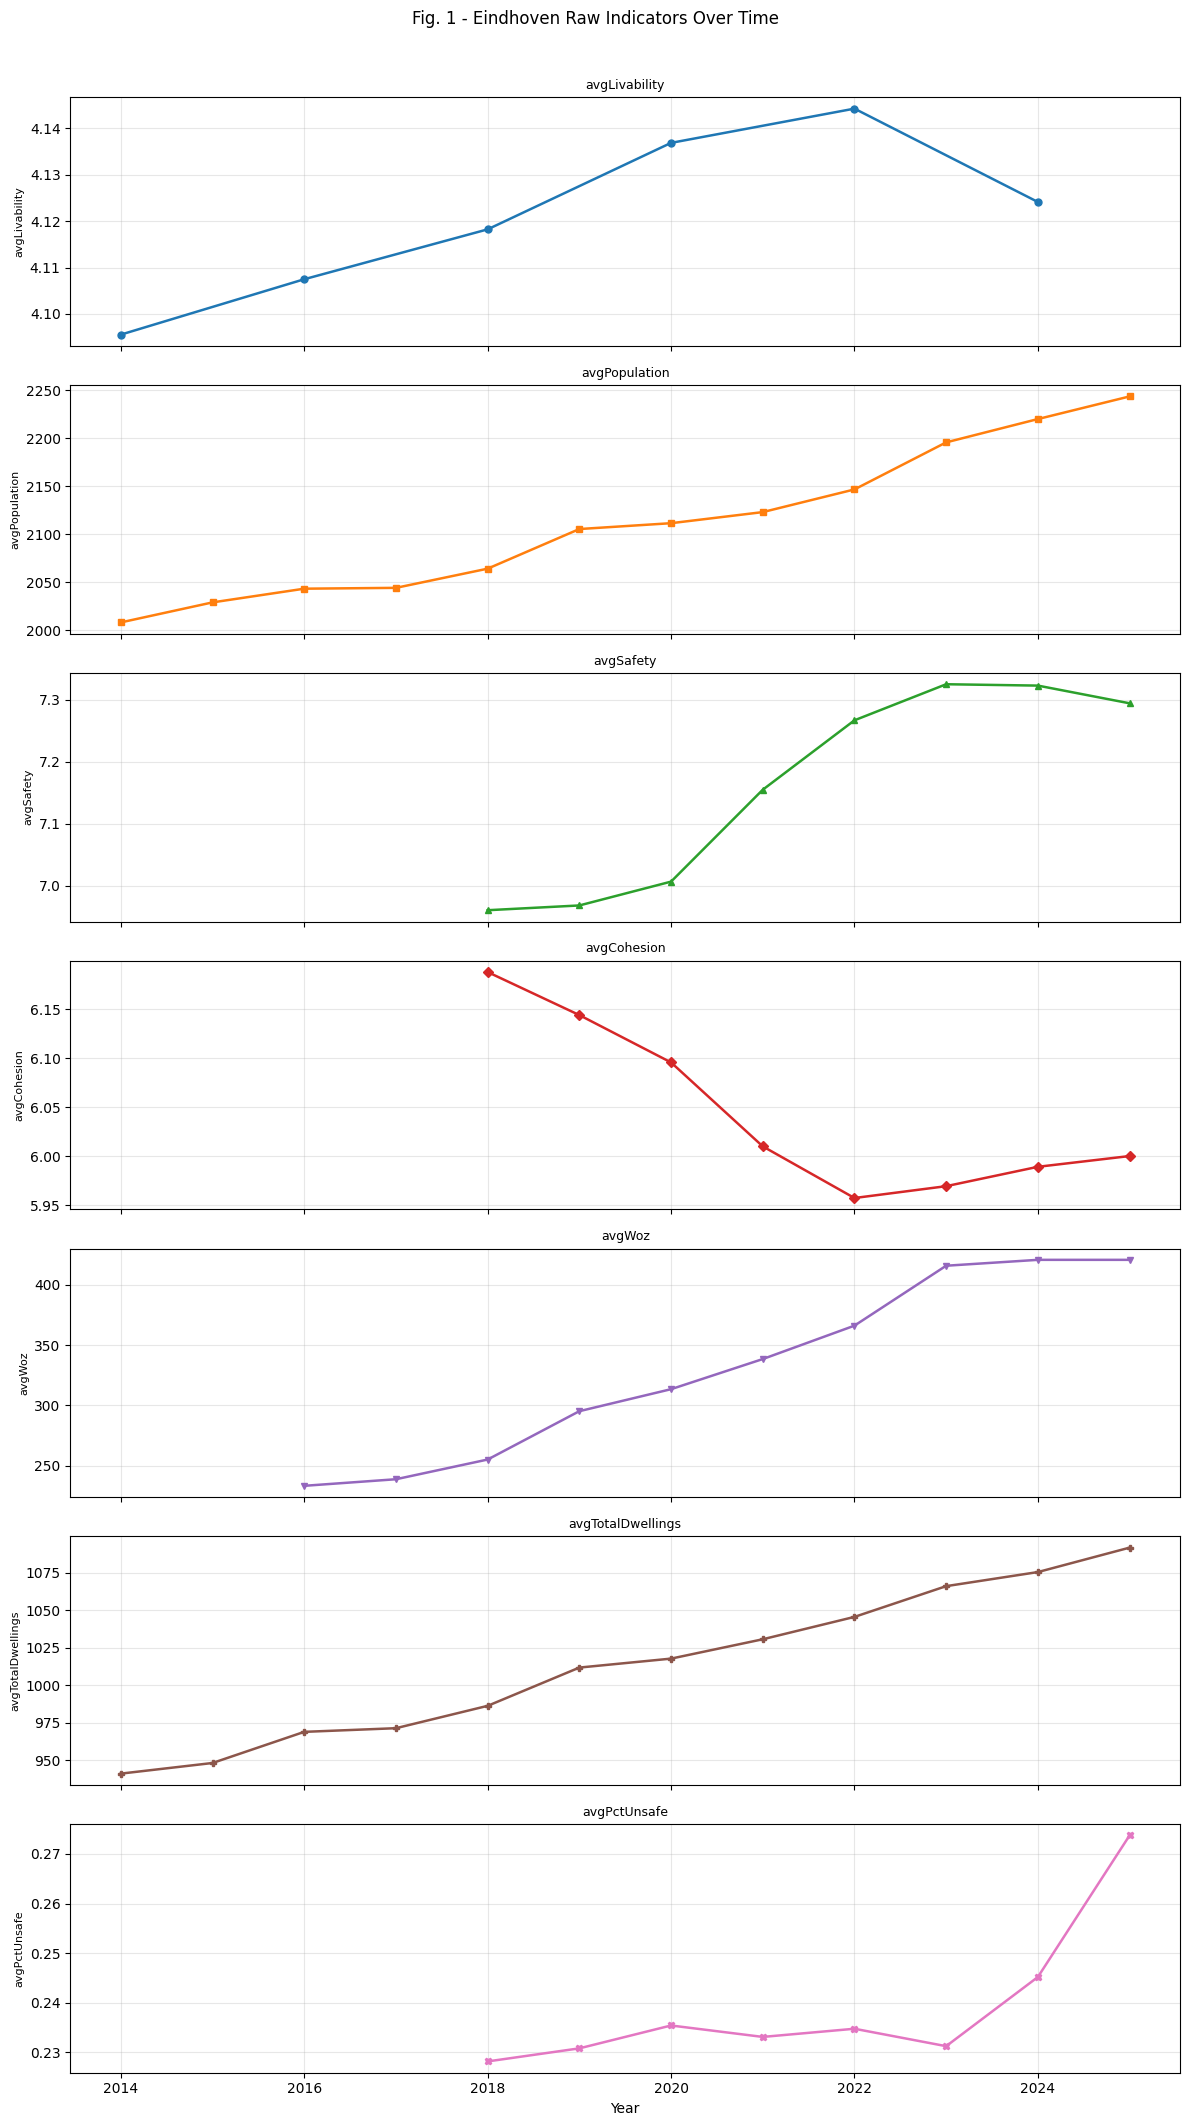

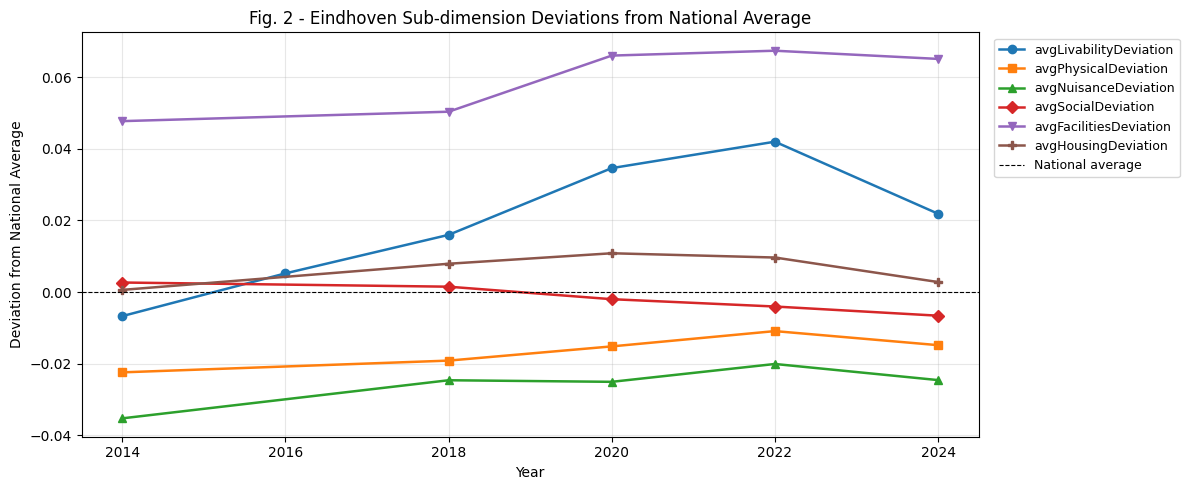

In [44]:
raw_cols = [
    "avgLivability", "avgPopulation", "avgSafety",
    "avgCohesion", "avgWoz", "avgTotalDwellings", "avgPctUnsafe"
]

# Normalize only raw columns, not deviations, because they can be negative.
available_raw = [c for c in raw_cols if c in q1_leef.columns and q1_leef[c].notna().any()]

# We define the source for each column to show all available data.
col_source = {
    "avgLivability":     q1_leef,
    "avgPopulation":     q1_df,
    "avgSafety":         q1_df,
    "avgCohesion":       q1_df,
    "avgWoz":            q1_df,
    "avgTotalDwellings": q1_df,
    "avgPctUnsafe":      q1_df,
}

# Styling of the line points and colors.
colors = plt.cm.tab10.colors
styles = ["-o", "-s", "-^", "-D", "-v", "-P", "-X", "-*", "-h"]

# Plotting the raw indicators over time (normalized).
fig, axes = plt.subplots(len(available_raw), 1, 
                          figsize=(12, 3 * len(available_raw)), 
                          sharex=True)

for i, col in enumerate(available_raw):
    ax = axes[i]
    source_df = col_source.get(col, q1_df)
    subset = source_df[source_df[col].notna()]

    ax.plot(subset["year"], subset[col],
            styles[i % len(styles)],
            color=colors[i % len(colors)],
            linewidth=1.8, markersize=5)

    ax.set_ylabel(col, fontsize=8)
    ax.set_title(col, fontsize=9)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("Year")
fig.suptitle("Fig. 1 - Eindhoven Raw Indicators Over Time", 
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig("../output/rq1_query1_raw_indicators.png", dpi=150, bbox_inches="tight")
plt.show()

dev_cols = [
    "avgLivabilityDeviation",
    "avgPhysicalDeviation", "avgNuisanceDeviation", "avgSocialDeviation",
    "avgFacilitiesDeviation", "avgHousingDeviation"
]

# Plotting the sub-dimension deviations from 2018 national average (calibration point) for measurement years only.
available_dev = [c for c in dev_cols if c in q1_leef.columns and q1_leef[c].notna().any()]

fig, ax = plt.subplots(figsize=(12, 5))

for i, col in enumerate(available_dev):
    subset = q1_leef[q1_leef[col].notna()].copy()
    subset[col] = pd.to_numeric(subset[col], errors="coerce")
    ax.plot(subset["year"], subset[col],
            styles[i % len(styles)],
            color=colors[i % len(colors)],
            label=col, linewidth=1.8, markersize=6)

ax.axhline(0, color="black", linewidth=0.8, linestyle="--", label="National average")
ax.set_xlabel("Year")
ax.set_ylabel("Deviation from National Average")
ax.set_title("Fig. 2 - Eindhoven Sub-dimension Deviations from National Average")
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("../output/rq1_query1_deviations.png", dpi=150)
plt.show()

In [22]:
print(q1_df[["year", "dimensionScoresAvailable", 
             "surveyAvailable", "wozAvailable"]].to_string(index=False))

 year  dimensionScoresAvailable  surveyAvailable  wozAvailable
 2014                      True            False         False
 2015                     False            False         False
 2016                     False            False          True
 2017                     False            False          True
 2018                      True             True          True
 2019                     False             True          True
 2020                      True             True          True
 2021                     False             True          True
 2022                      True             True          True
 2023                     False             True          True
 2024                      True             True          True
 2025                     False             True          True


**Fig. 1** - 
- Livability (blue) rises steadily from 2014 to 2022, then drops sharply in 2024 which is a relevant observation aligning with the client's concerns.
- Population (orange) and Total Dwellings (brown) both grow continuously throughout the entire period, very similarly in their growth, suggesting that housing supply is trying to match demand.
    - We would expect to see the housing supply taper off if there was more supply than demand, but this is not the case.
- Safety (green) shows a sharp improvement from 2018 to 2022, but then plateaus, eventually declining in 2025.
- Cohesion (red) starts in 2018 and shows a consistent decline throughout, never recovering.
    - This marks a meaningful deterioration in resident social cohesion.
- Percentage unsafe (pink) spikes sharply in 2024–2025, which is very alarming.
- WOZ values (purple) rise steeply and continuously, which is strange given the livability falling, suggesting that market forces have increased housing prices as opposed to quality of life.
- Percentage feeling unsafe (pink) rises steadily from 2018 onward, which aligns with the population growth.
    - Urbanity class would be a useful analysis extension here, to see if population density relates to safety concerns.
- The 2024 livability drop is the sharpest single movement in the entire dataset and coincides with the highest population and highest percentage feeling unsafe.

**Fig. 2** - 
- Overall livability deviation (blue) was initially negative in 2014 (-0.013), meaning that Eindhoven was below the national average from 2018 (calibration year). It eventually became positive around 2015-2016, peaking in 2022, before reducing sharply in comparison to its prior performance.
- Nuisance and insecurity (green) is the most consistently negative deviation in the dataset, consistently around -0.024 to -0.035 across all measurement years. Eindhoven structurally underperforms with respect to the national average, showing no meaningful improvement.
- Physical environment (orange) is also consistently negative but slowly improving — from -0.022 in 2014 to -0.013 in 2024.
- Social cohesion deviation (red) is the most alarming trend as it started slightly positive in 2014, but has been negative and worsening since 2018.
- Facilities (purple) is Eindhoven's strongest dimension, consistently +0.048 to +0.067 above the national average, though showing a slight decline in 2024.
- Housing stock (brown) maintains a small positive deviation but has declined sharply from +0.011 in 2020 to +0.003 in 2024, approaching the national average, consistent with the housing pressure identified in Fig. 1.
- Neither nuisance nor physical environment have crossed below -0.04, and neither facilities nor housing have turned negative. However, the directional trends for social cohesion and housing are the most policy-relevant signals in this chart.

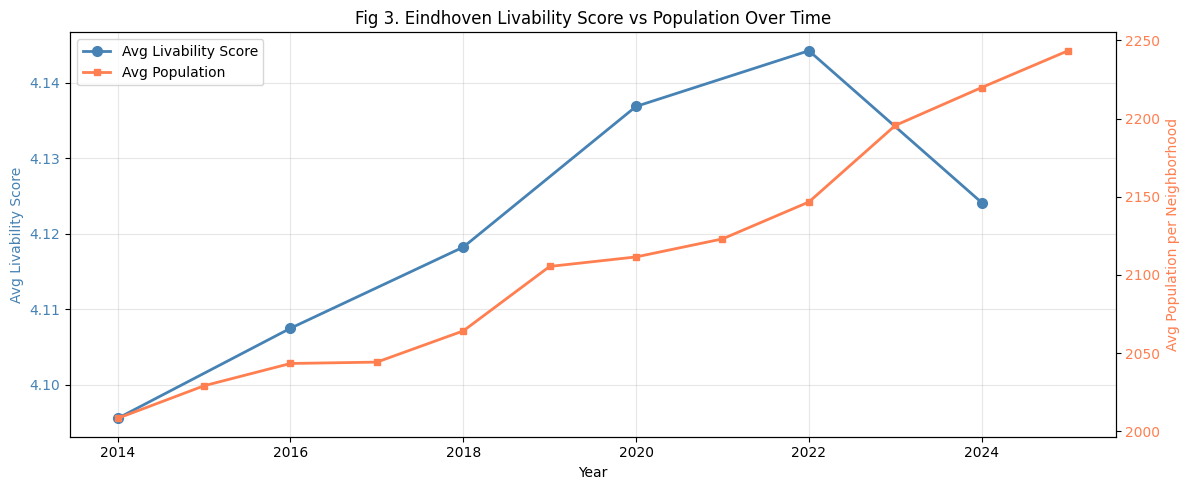

In [45]:
fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.plot(q1_leef["year"], q1_leef["avgLivability"],
         "-o", color="steelblue", linewidth=2, markersize=7, label="Avg Livability Score")
ax1.set_xlabel("Year")
ax1.set_ylabel("Avg Livability Score", color="steelblue")
ax1.tick_params(axis="y", labelcolor="steelblue")

ax2 = ax1.twinx()
ax2.plot(q1_df["year"], q1_df["avgPopulation"],
         "-s", color="coral", linewidth=2, markersize=5, label="Avg Population")
ax2.set_ylabel("Avg Population per Neighborhood", color="coral")
ax2.tick_params(axis="y", labelcolor="coral")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")
ax1.set_title("Fig 3. Eindhoven Livability Score vs Population Over Time")
ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("../output/rq1_query1_livability_vs_population.png", dpi=150)
plt.show()

**Fig 3.** - 
- From 2014 to 2022 both livability and population rise together, meaning that population growth did not hurt livability during this period.
- In 2024 livability drops sharply while population continues rising which shows the first divergence between the series.
- Population growth alone clearly does not explain falling livability as they moved in the same direction for 8 years before diverging.

In [46]:
# We get year-over-year deltas for the measurement years only.
pop_at_measurement = q1_df[q1_df["year"].isin(q1_leef["year"])][["year", "avgPopulation"]]
q1_leef = q1_leef.merge(pop_at_measurement, on="year", how="left", suffixes=("", "_annual"))

q1_leef["livabilityDelta"] = pd.to_numeric(q1_leef["avgLivability"], errors="coerce").diff()
q1_leef["populationDelta"] = pd.to_numeric(q1_leef["avgPopulation"], errors="coerce").diff()

print("\nYear-over-year livability changes (measurement years only):")
print(q1_leef[["year", "avgLivability", "livabilityDelta",
               "avgPopulation", "populationDelta"]].to_string(index=False))


Year-over-year livability changes (measurement years only):
 year avgLivability  livabilityDelta  avgPopulation  populationDelta
 2014      4.095546              NaN    2008.336364              NaN
 2016      4.107482         0.011936    2043.418182        35.081818
 2018      4.118234         0.010752    2064.243243        20.825061
 2020      4.136874         0.018641    2111.549550        47.306306
 2022      4.144255         0.007381    2146.675676        35.126126
 2024      4.124135        -0.020120    2219.873874        73.198198


From the table above, we can make some key observations:
- Livability rose consistently from 2014 to 2022, then fell sharply in 2024.
    - Every measurement period from 2014–2022 showed a positive livability delta, but the 2024 delta of -0.020 is the only negative value in the entire series and is larger in magnitude than any single positive gain.
- The largest population increase coincided with the largest livability drop.
    - Causation cannot be established from this alone.
- Population growth was not harmful during earlier periods.
    - 2018→2020 had the second highest population delta (+47.3) yet also had the highest positive livability delta (+0.019) showing that population growth alone does not determine livability direction.

In [47]:
# No replace(0, pd.NA) needed — flags already handled missingness above
q1_leef["wozDelta"]    = pd.to_numeric(q1_leef["avgWoz"],    errors="coerce").diff()
q1_leef["safetyDelta"] = pd.to_numeric(q1_leef["avgSafety"], errors="coerce").diff()

print(q1_leef[["year", "avgWoz", "wozDelta",
               "avgSafety", "safetyDelta"]].to_string(index=False))

 year     avgWoz  wozDelta  avgSafety  safetyDelta
 2014        NaN       NaN        NaN          NaN
 2016 233.361702       NaN        NaN          NaN
 2018 255.157895 21.796193   6.960440          NaN
 2020 313.505051 58.347156   7.006593     0.046154
 2022 366.188119 52.683068   7.267033     0.260440
 2024 420.772277 54.584158   7.323077     0.056044


From the table above, we can make some key observations:
- Average property values rose from €255,000 in 2018 to €421,000 in 2024 which is a 65% increase over six years. 
- Resident safety ratings improved from 6.96 in 2018 to 7.32 in 2024, but the rate of improvement decelerated sharply from +0.26 between 2020 and 2022 to only +0.056 between 2022 and 2024.

## Query 2 - Weighted Average Livability Score Comparison

In [57]:
q2_df = pd.read_csv('../data/processed/rq1-q2.csv')
q2_df.columns = q2_df.columns.str.strip()
q2_df["year"] = pd.to_numeric(q2_df["year"], errors="coerce").astype(int)
q2_df = q2_df.sort_values("year").reset_index(drop=True)

# Coerce numeric columns
numeric_cols = [
    "weightedAvgLivability", "weightedAvgDeviation",
    "weightedFacilitiesDeviation", "weightedHousingDeviation",
    "weightedSafetyRating", "weightedPctUnsafe", "totalPopulation"
]
for col in numeric_cols:
    q2_df[col] = pd.to_numeric(q2_df[col], errors="coerce")

# Apply flags — same logic as Query 1
dim_cols    = ["weightedFacilitiesDeviation", "weightedHousingDeviation",
               "weightedAvgDeviation"]
survey_cols = ["weightedSafetyRating", "weightedPctUnsafe"]

for col in dim_cols:
    q2_df.loc[~q2_df["dimensionScoresAvailable"], col] = pd.NA

for col in survey_cols:
    q2_df.loc[~q2_df["surveyAvailable"], col] = pd.NA

# Measurement years only
q2_leef = q2_df[q2_df["weightedAvgLivability"].notna()].copy().reset_index(drop=True)

q2_df.head()

,year,weightedAvgLivability,weightedAvgDeviation,weightedFacilitiesDeviation,weightedHousingDeviation,weightedSafetyRating,weightedPctUnsafe,totalPopulation,avgPopulation,dimensionScoresAvailable,surveyAvailable,wozAvailable
0,2014,4.036564,-0.065701,0.051504,-0.013817,NaN,NaN,220615.0,2023.990826,True,False,False
1,2016,4.053941,NaN,NaN,NaN,NaN,NaN,224490.0,2059.541284,False,False,True
2,2018,4.061295,-0.040970,0.053483,-0.009613,6.820387,0.237723,228844.0,2080.400000,True,True,True
3,2020,4.086707,-0.015558,0.070727,-0.004984,6.867570,0.246191,234086.0,2128.054545,True,True,True
4,2022,4.100716,-0.001549,0.071992,-0.004107,7.134408,0.240627,237991.0,2163.554545,True,True,True


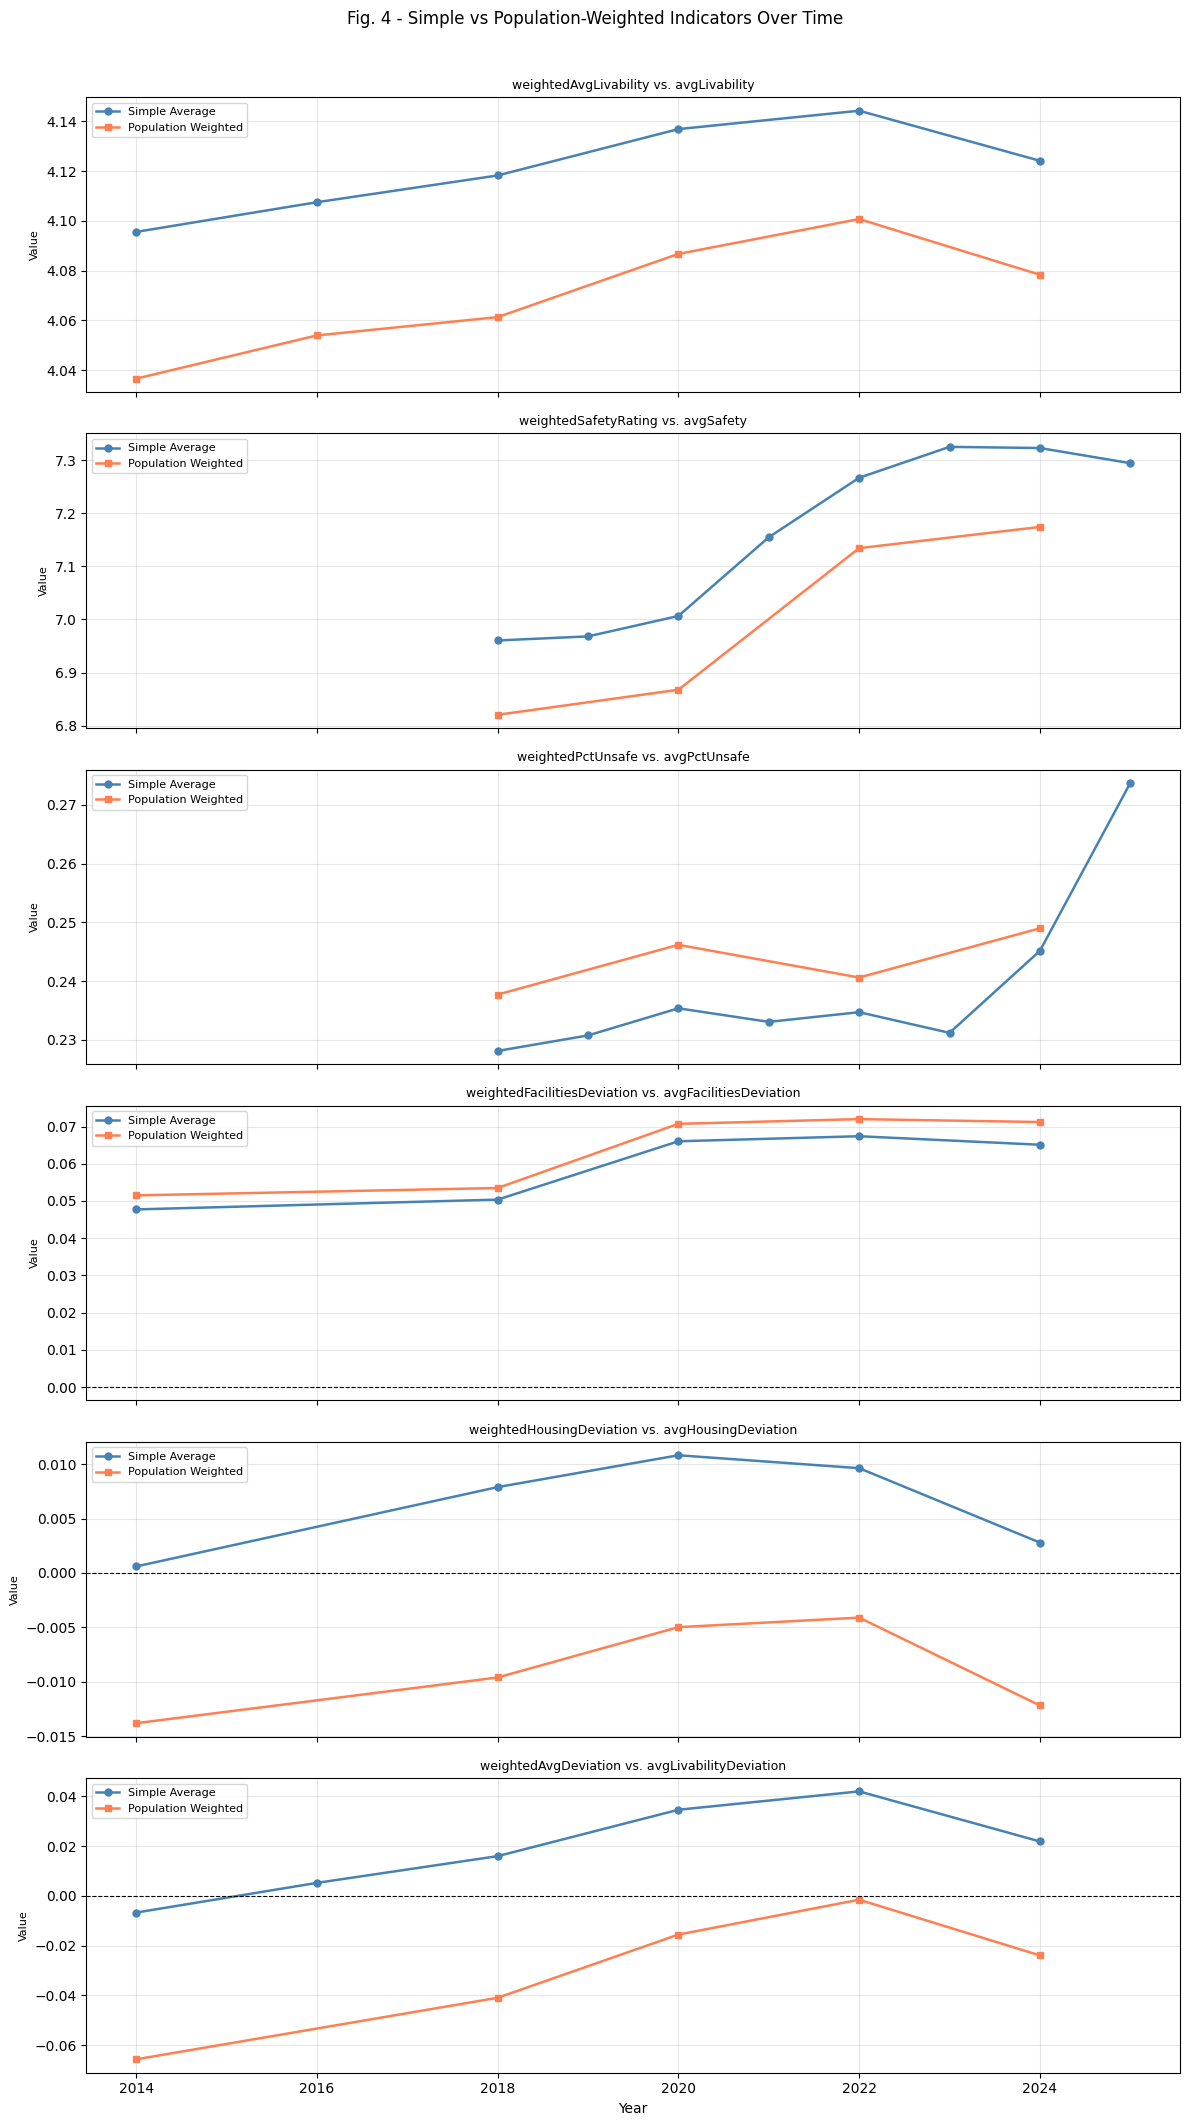

In [60]:
# Map weighted column to its simple average equivalent from Query 1
col_mapping = {
    "weightedAvgLivability":       ("avgLivability",       q1_leef, q2_leef),
    "weightedSafetyRating":        ("avgSafety",            q1_df,   q2_df),
    "weightedPctUnsafe":           ("avgPctUnsafe",         q1_df,   q2_df),
    "weightedFacilitiesDeviation": ("avgFacilitiesDeviation", q1_leef, q2_leef),
    "weightedHousingDeviation":    ("avgHousingDeviation",  q1_leef, q2_leef),
    "weightedAvgDeviation":        ("avgLivabilityDeviation", q1_leef, q2_leef),
}

fig, axes = plt.subplots(len(col_mapping), 1,
                          figsize=(12, 3.5 * len(col_mapping)),
                          sharex=True)

for i, (weighted_col, (simple_col, simple_df, weighted_df)) in enumerate(col_mapping.items()):
    ax = axes[i]

    # Simple average line
    if simple_col in simple_df.columns:
        simple_subset = simple_df[simple_df[simple_col].notna()]
        ax.plot(simple_subset["year"], simple_subset[simple_col],
                "-o", color="steelblue", linewidth=1.8, markersize=5,
                label="Simple Average")

    # Weighted average line
    if weighted_col in weighted_df.columns:
        weighted_subset = weighted_df[weighted_df[weighted_col].notna()]
        ax.plot(weighted_subset["year"], weighted_subset[weighted_col],
                "-s", color="coral", linewidth=1.8, markersize=5,
                label="Population Weighted")

    ax.set_title(f"{weighted_col} vs. {simple_col}", fontsize=9)
    ax.set_ylabel("Value", fontsize=8)
    ax.legend(fontsize=8, loc="upper left")
    ax.grid(True, alpha=0.3)

    # Add zero reference line for deviation plots
    if "Deviation" in weighted_col:
        ax.axhline(0, color="black", linewidth=0.8, linestyle="--")

axes[-1].set_xlabel("Year")
fig.suptitle("Fig. 4 - Simple vs Population-Weighted Indicators Over Time",
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig("../output/rq1_query2_weighted_vs_simple.png", dpi=150,
            bbox_inches="tight")
plt.show()

**Fig. 4** - 
- **Livability** - The population-weighted average is consistently below the simple average across all years, meaning that larger neighborhoods are systematically less livable than smaller ones.
    - Both lines follow the same trend, as they rise till 2022 but drop sharply in 2024, which confirms that the 2024 decline is a genuine city-wide phenomenon.
    - The gap between the two lines remains stable, suggesting that the relationship between neighborhood size and livability has not changed dramatically over time.
- **Safety** - The weighted safety rating is consistently lower than the simple average by ~0.1–0.15 points, meaning that larger neighborhoods feel less safe than smaller ones.
    - The gap widens slightly over time, suggesting larger neighborhoods are falling behind on safety improvement relative to smaller ones.
- **Percentage Unsafe** - The weighted percentage feeling unsafe is higher than the simple average throughout as larger neighborhoods have more residents feeling unsafe.
- **Facilities Deviation** - The weighted facilities deviation is higher than the simple average as larger neighborhoods have better facility access than smaller ones.
- **Housing Deviation** - The simple average is positive throughout (+0.001 to +0.010) while the weighted average is consistently negative (-0.013 to -0.004).
    - Although the simple average shows a similar decline, the key insight is that Eindhoven's apparent housing stock advantage over the national average is entirely an artifact of small neighborhoods.
    - The weighted version worsens sharply in 2024 (-0.012), suggesting housing conditions in larger neighborhoods are deteriorating faster than the national average.
- **Livability Deviation** - The weighted deviation is dramatically more negative than the simple average throughout.
    - This is the most important finding from this query: the narrative that Eindhoven is above the national average on livability is driven by small high-scoring neighborhoods, not by the experience of the majority of residents.

## Query 3 - Year-over-Year Differences

In [68]:
q3_df = pd.read_csv('../data/processed/rq1-q3.csv')
q3_df.columns = q3_df.columns.str.strip()

delta_cols = [
    "livabilityDelta", "populationDelta", "dwellingsDelta",
    "wozDelta", "safetyDelta", "facilitiesDeviationDelta", "housingDeviationDelta"
]
for col in delta_cols:
    q3_df[col] = pd.to_numeric(q3_df[col], errors="coerce")

q3_df["year1"] = pd.to_numeric(q3_df["year1"], errors="coerce").astype(int)
q3_df["year2"] = pd.to_numeric(q3_df["year2"], errors="coerce").astype(int)

print(f"Shape: {q3_df.shape}")
q3_df.head(10)

Shape: (548, 10)


,neighborhood,year1,year2,livabilityDelta,populationDelta,dwellingsDelta,wozDelta,safetyDelta,facilitiesDeviationDelta,housingDeviationDelta
0,'t Hofke,2014,2016,0.038799,-93.0,4.0,NaN,NaN,NaN,NaN
1,'t Hofke,2016,2018,-0.026620,-24.0,1.0,19.0,NaN,NaN,NaN
2,'t Hofke,2018,2020,-0.004288,227.0,311.0,7.0,-0.2,0.021971,-0.002077
3,'t Hofke,2020,2022,0.037231,54.0,1.0,38.0,0.4,-0.002808,-0.074635
4,'t Hofke,2022,2024,-0.018057,54.0,84.0,31.0,0.1,0.008479,-0.022655
5,'t Hool,2014,2016,0.004264,13.0,1.0,NaN,NaN,NaN,NaN
6,'t Hool,2016,2018,0.025541,92.0,7.0,14.0,NaN,NaN,NaN
7,'t Hool,2018,2020,0.023062,52.0,5.0,37.0,-0.2,0.009649,0.008079
8,'t Hool,2020,2022,-0.017111,-14.0,1.0,48.0,0.5,-0.006949,-0.006591
9,'t Hool,2022,2024,-0.013259,56.0,4.0,44.0,-0.3,-0.004911,-0.015101


In [69]:
# We compute Pearson correlations between livabilityDelta and other deltas, only on rows where both are present.
correlations = {}
for col in delta_cols[1:]:  # Skip livabilityDelta itself
    valid = q3_df[["livabilityDelta", col]].dropna()
    if len(valid) < 10:
        print(f"{col}: insufficient data ({len(valid)} rows)")
        continue
    r, p = stats.pearsonr(valid["livabilityDelta"], valid[col])
    correlations[col] = {"r": r, "p": p, "n": len(valid)}
    significance = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else ""
    print(f"{col:<35} r={r:+.3f}  p={p:.4f} {significance}")

populationDelta                     r=-0.084  p=0.0503 
dwellingsDelta                      r=-0.051  p=0.2350 
wozDelta                            r=+0.007  p=0.8841 
safetyDelta                         r=+0.080  p=0.1853 
facilitiesDeviationDelta            r=+0.243  p=0.0000 ***
housingDeviationDelta               r=+0.526  p=0.0000 ***


From the table above, we make the following observations:
- **housingDeviationDelta** - When Eindhoven's housing stock sub-dimension improves relative to the national average, livability also improves.
- **facilitiesDeviationDelta** - When facility access improves relative to the national average, livability improves. 
    - The effect is weaker than housing but still meaningful and reliable.
- **populationDelta** - There is a very weak tendency for livability to decline as population grows, but it is not statistically reliable enough to conclude a causal relationship.
- **dwellingsDelta** - No significant relationship between adding dwellings and livability change.
- **wozDelta** - Rising property values have no meaningful relationship with livability change at the neighborhood level.
- **safetyDelta** - Positive direction as expected but not statistically significant, likely due to the reduced sample size from survey availability starting only in 2018.

The correlation analysis is conducted on ~548 neighborhood-year pairs for population and dwelling deltas, which is sufficient for reliable inference. However, safety and WOZ deltas have reduced sample sizes due to their later start dates (2018 and 2016 respectively), meaning non-significance for these indicators should be interpreted cautiously rather than as evidence of no relationship.

In [64]:
# We look at the percentage of neighborhood-year pairs where population grew, and among those, the share where livability fell.
valid_q3 = q3_df[["livabilityDelta", "populationDelta"]].dropna()

pop_up_liv_down = (
    (valid_q3["populationDelta"] > 0) &
    (valid_q3["livabilityDelta"] < 0)
).sum()

pop_up = (valid_q3["populationDelta"] > 0).sum()
total  = len(valid_q3)

print(f"\nTotal neighborhood-year pairs: {total}")
print(f"Pairs where population grew: {pop_up} ({pop_up/total*100:.1f}%)")
print(f"Pairs where population grew AND livability fell: {pop_up_liv_down} ({pop_up_liv_down/total*100:.1f}%)")
print(f"Of growing-population pairs, share with livability decline: {pop_up_liv_down/pop_up*100:.1f}%")


Total neighborhood-year pairs: 548
Pairs where population grew: 328 (59.9%)
Pairs where population grew AND livability fell: 147 (26.8%)
Of growing-population pairs, share with livability decline: 44.8%


Nearly half of all cases where a neighborhood grew in population also saw livability worsen in the same period. This is substantially higher than would be expected by chance and provides neighborhood-level evidence that population growth and livability decline frequently co-occur.
- The inverse is also true, as 55.2% of growing-population pairs saw livability improve or stay stable. 
- So population growth does not inevitably lead to livability decline, consistent with the earlier city-level finding. 

In [70]:
# Flagging pairs where population grew but livability fell.
q3_df["stress"] = (
    (q3_df["populationDelta"] > 0) &
    (q3_df["livabilityDelta"] < 0)
)

stress_summary = (
    q3_df.groupby("neighborhood")["stress"]
    .agg(["sum", "count"])
    .rename(columns={"sum": "stress_periods", "count": "total_periods"})
    .reset_index()
)
stress_summary["stress_pct"] = (
    stress_summary["stress_periods"] / stress_summary["total_periods"] * 100
).round(1)

persistent = stress_summary[
    stress_summary["stress_periods"] >= 3
].sort_values("stress_periods", ascending=False)

print(f"\nNeighborhoods with population growth + livability decline in 3+ periods:")
print(persistent.to_string(index=False))

# Profile of persistently stressed neighborhoods
stressed_neighborhoods = persistent["neighborhood"].tolist()

profile = q3_df[q3_df["neighborhood"].isin(stressed_neighborhoods)].groupby("neighborhood")[
    ["populationDelta", "dwellingsDelta", "facilitiesDeviationDelta",
     "housingDeviationDelta", "livabilityDelta"]
].mean().round(3)

print("\nAverage deltas for persistently stressed neighborhoods:")
print(profile.to_string())


Neighborhoods with population growth + livability decline in 3+ periods:
 neighborhood  stress_periods  total_periods  stress_pct
         Bokt               3              5        60.0
 Castiliëlaan               3              5        60.0
Genneperzijde               3              5        60.0
 Hondsheuvels               3              5        60.0
    Kronehoef               3              5        60.0
  Rapelenburg               3              5        60.0

Average deltas for persistently stressed neighborhoods:
               populationDelta  dwellingsDelta  facilitiesDeviationDelta  housingDeviationDelta  livabilityDelta
neighborhood                                                                                                    
Bokt                       0.2             1.0                    -0.002                 -0.002            0.009
Castiliëlaan              95.8            52.2                    -0.001                 -0.154           -0.106
Genneperzijde     

Six neighborhoods experienced population growth alongside livability decline in 3 out of 5 measurement periods (60% of the time).
- These are the most persistently stressed neighborhoods in Eindhoven and the most policy-relevant cases for the municipality.

For each neighborhood, we included a brief analysis below:
- **Castiliëlaan** - Average population growth of +95.8 per period with a housing deviation delta of -0.154, a very large negative housing deviation. 
    - This neighborhood is experiencing rapid population growth alongside housing shortage relative to national standards, producing the largest average livability decline (-0.106) in the group. 
    - This is the highest priority case for municipal intervention.
- **Kronehoef** - Highest absolute population growth (+152.6 per period) and dwelling growth (+106.2), yet livability is essentially flat (+0.004).
- **Rapelenburg** - Significant population growth (+108.0) with dwelling growth lagging (+73.2), negative housing deviation delta (-0.026), and consistent livability decline (-0.020).
- **Hondsheuvels** - Moderate population growth (+24.6) but dwelling growth is very low (+6.6) — the worst dwelling supply ratio in the group. 
- **Genneperzijde** - Moderate growth (+27.4) with relatively matched dwelling growth (+18.0) and slightly positive housing and facilities deviations.
- **Bokt** - Very small population growth (+0.2) and dwelling growth (+1.0), minimal deviation changes, and a slightly positive livability delta (+0.009).


Population vs Dwelling Growth Summary:
Avg population delta: 46.2
Avg dwellings delta:  28.7
Avg dwellings added per resident: inf

Average deltas by measurement period:
             populationDelta  dwellingsDelta
year1 year2                                 
2014  2016              35.6            28.1
2016  2018              38.4            25.1
2018  2020              47.7            31.8
2020  2022              35.5            28.1
2022  2024              73.6            30.2


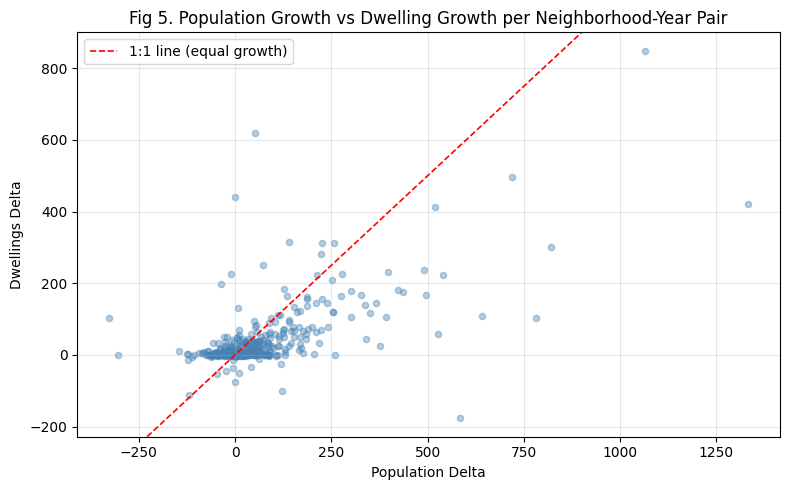

In [71]:
valid_dw = q3_df[["neighborhood", "year1", "year2",
                   "populationDelta", "dwellingsDelta",
                   "livabilityDelta"]].dropna()

valid_dw["dwellings_per_resident"] = (
    valid_dw["dwellingsDelta"] / valid_dw["populationDelta"]
)

print("\nPopulation vs Dwelling Growth Summary:")
print(f"Avg population delta: {valid_dw['populationDelta'].mean():.1f}")
print(f"Avg dwellings delta:  {valid_dw['dwellingsDelta'].mean():.1f}")
print(f"Avg dwellings added per resident: {valid_dw['dwellings_per_resident'].mean():.3f}")

by_year = valid_dw.groupby(["year1", "year2"])[
    ["populationDelta", "dwellingsDelta"]
].mean().round(1)
print("\nAverage deltas by measurement period:")
print(by_year.to_string())

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(valid_dw["populationDelta"], valid_dw["dwellingsDelta"],
           alpha=0.4, color="steelblue", s=20)
ax.axline((0, 0), slope=1, color="red", linestyle="--",
          linewidth=1.2, label="1:1 line (equal growth)")
ax.set_xlabel("Population Delta")
ax.set_ylabel("Dwellings Delta")
ax.set_title("Fig 5. Population Growth vs Dwelling Growth per Neighborhood-Year Pair")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("../output/rq1_q3_population_vs_dwellings.png", dpi=150)
plt.show()

**Fig. 5** - 
- The majority of points cluster below the 1:1 line which means that across most neighborhood-year pairs, population growth outpaced dwelling growth. This is the central finding: housing supply is not keeping pace with population demand in most cases.
- The dense cluster near (0,0) shows that most neighborhoods experience modest changes in both population and dwellings per period, with small positive population growth and near-zero dwelling growth. 
    - This suggests most neighborhoods are absorbing more residents into an essentially static housing stock.
- A small number of neighborhoods added significantly more dwellings than residents, likely new development areas where construction preceded population arrival.
- The fastest growing neighborhoods are precisely the ones where dwelling supply is most inadequate relative to demand.
- Some neighborhoods lost population while dwellings remained stable or even grew, suggesting outmigration rather than housing shortage in those cases.


Correlation: populationDelta vs facilitiesDeviationDelta
r=+0.027, p=0.6247

Avg population and facilities deviation delta by period:
             populationDelta  facilitiesDeviationDelta
year1 year2                                           
2018  2020           47.6545                    0.0157
2020  2022           35.5000                    0.0014
2022  2024           73.6273                   -0.0023


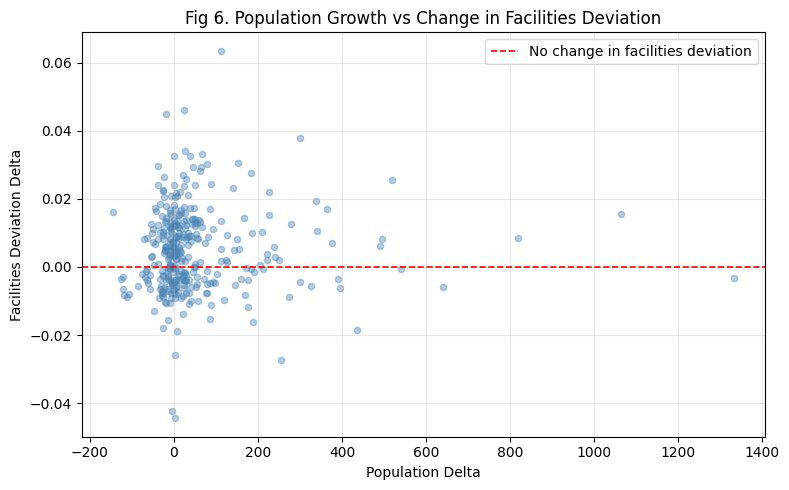

In [72]:
# Repeating the same process for facilities deviation delta instead of dwellings delta.
valid_fac = q3_df[["neighborhood", "year1", "year2",
                    "populationDelta", "facilitiesDeviationDelta",
                    "livabilityDelta"]].dropna()

r_fac, p_fac = stats.pearsonr(
    valid_fac["populationDelta"],
    valid_fac["facilitiesDeviationDelta"]
)
print(f"\nCorrelation: populationDelta vs facilitiesDeviationDelta")
print(f"r={r_fac:+.3f}, p={p_fac:.4f}")

by_year_fac = valid_fac.groupby(["year1", "year2"])[
    ["populationDelta", "facilitiesDeviationDelta"]
].mean().round(4)
print("\nAvg population and facilities deviation delta by period:")
print(by_year_fac.to_string())

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(valid_fac["populationDelta"], valid_fac["facilitiesDeviationDelta"],
           alpha=0.4, color="steelblue", s=20)
ax.axhline(0, color="red", linestyle="--", linewidth=1.2,
           label="No change in facilities deviation")
ax.set_xlabel("Population Delta")
ax.set_ylabel("Facilities Deviation Delta")
ax.set_title("Fig 6. Population Growth vs Change in Facilities Deviation")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("../output/rq1_q3_population_vs_facilities.png", dpi=150)
plt.show()

**Fig. 6** - 
- Most points cluster near zero on both axes as the majority of neighborhood-year pairs show modest population growth and small changes in facilities deviation, suggesting facilities are broadly stable relative to the national average for most neighborhoods most of the time.

## Query 4 - National Average Comparison

In [73]:
q4_df = pd.read_csv('../data/processed/rq1-q4.csv')
q4_df.columns = q4_df.columns.str.strip()
q4_df["year"] = pd.to_numeric(q4_df["year"], errors="coerce").astype(int)
q4_df = q4_df.sort_values("year").reset_index(drop=True)

dev_cols = [
    "avgLivabilityDeviation",
    "avgPhysicalDeviation", "avgNuisanceDeviation", "avgSocialDeviation",
    "avgFacilitiesDeviation", "avgHousingDeviation"
]

for col in dev_cols + ["avgLivability"]:
    q4_df[col] = pd.to_numeric(q4_df[col], errors="coerce")

dim_cols = [
    "avgLivabilityDeviation", "avgPhysicalDeviation", "avgNuisanceDeviation",
    "avgSocialDeviation", "avgFacilitiesDeviation", "avgHousingDeviation"
]
for col in dim_cols:
    q4_df.loc[~q4_df["dimensionScoresAvailable"], col] = pd.NA

q4_leef = q4_df[q4_df["avgLivability"].notna()].copy().reset_index(drop=True)

print(q4_df.to_string(index=False))

 year  avgLivability  avgLivabilityDeviation  avgPhysicalDeviation  avgNuisanceDeviation  avgSocialDeviation  avgFacilitiesDeviation  avgHousingDeviation  dimensionScoresAvailable
 2014       4.096813               -0.005452             -0.021650             -0.034525            0.002778                0.046776             0.001170                      True
 2016       4.108270                     NaN                   NaN                   NaN                 NaN                     NaN                  NaN                     False
 2018       4.119672                0.017407             -0.018360             -0.023800            0.001641                0.049543             0.008382                      True
 2020       4.138645                0.036380             -0.014403             -0.024059           -0.001665                0.065205             0.011302                      True
 2022       4.146113                0.043848             -0.010174             -0.018860           -

In [74]:
# We look at the mean deviation for each sub-dimension across all years, and whether it's consistently positive, negative, or mixed.
for col in dev_cols:
    values = q4_leef[col].dropna()
    n_negative = (values < 0).sum()
    n_positive = (values > 0).sum()
    mean_val   = values.mean()
    print(f"{col:<35} mean={mean_val:+.4f}")

avgLivabilityDeviation              mean=+0.0229
avgPhysicalDeviation                mean=-0.0157
avgNuisanceDeviation                mean=-0.0251
avgSocialDeviation                  mean=-0.0014
avgFacilitiesDeviation              mean=+0.0583
avgHousingDeviation                 mean=+0.0069


From the results above, we can see that nuisance (mean=-0.025) is the worst performing dimension, meaning Eindhoven consistently experiences more nuisance and insecurity than the national average. Additionally, physical environment (mean=-0.016) is the second weakest, showing structural underperformance throughout. Social cohesion (mean=-0.001) is marginally negative overall.

Facilities (mean=+0.058) is the strongest dimension by far, showing Eindhoven's clearest competitive advantage over the national average. Meanwhile, Housing (mean=+0.007) is positive but small and eroding rapidly toward zero.

In [75]:
# We also look at the trend over time for each sub-dimension: is it improving, worsening, or stable?
for col in dev_cols:
    valid = q4_leef[["year", col]].dropna()
    if len(valid) < 2:
        print(f"{col:<35} insufficient data")
        continue
    first = valid.iloc[0]
    last  = valid.iloc[-1]
    delta = last[col] - first[col]
    print(f"{col:<35} {int(first['year'])}={first[col]:+.4f} → "
          f"{int(last['year'])}={last[col]:+.4f}  Δ={delta:+.4f}")

avgLivabilityDeviation              2014=-0.0055 → 2024=+0.0225  Δ=+0.0280
avgPhysicalDeviation                2014=-0.0216 → 2024=-0.0140  Δ=+0.0076
avgNuisanceDeviation                2014=-0.0345 → 2024=-0.0242  Δ=+0.0103
avgSocialDeviation                  2014=+0.0028 → 2024=-0.0062  Δ=-0.0090
avgFacilitiesDeviation              2014=+0.0468 → 2024=+0.0637  Δ=+0.0169
avgHousingDeviation                 2014=+0.0012 → 2024=+0.0033  Δ=+0.0022


From the results above, comparing 2014 to 2024:
- **Facilities (Δ=+0.017)** — strongest sub-dimension improvement, Eindhoven's facility advantage over the national average grew over the decade.
- **Nuisance (Δ=+0.010) and Physical Environment (Δ=+0.008)** — despite remaining negative throughout, the gap with the national average is narrowing, indicating gradual relative improvement on these dimensions.
- **Overall Livability Deviation (Δ=+0.028)** — the largest positive delta overall, reflecting Eindhoven's transition from below to above the national average between 2014 and 2024.
- **Housing (Δ=+0.002)** — marginal improvement over the full period, though the trend analysis showed sharp deterioration in recent years masking this long-run gain.
- **Social Cohesion (Δ=-0.009)** — the only dimension to worsen over the full 2014–2024 period, shifting from a slight advantage (+0.003) to a deficit (-0.006) relative to the national average.

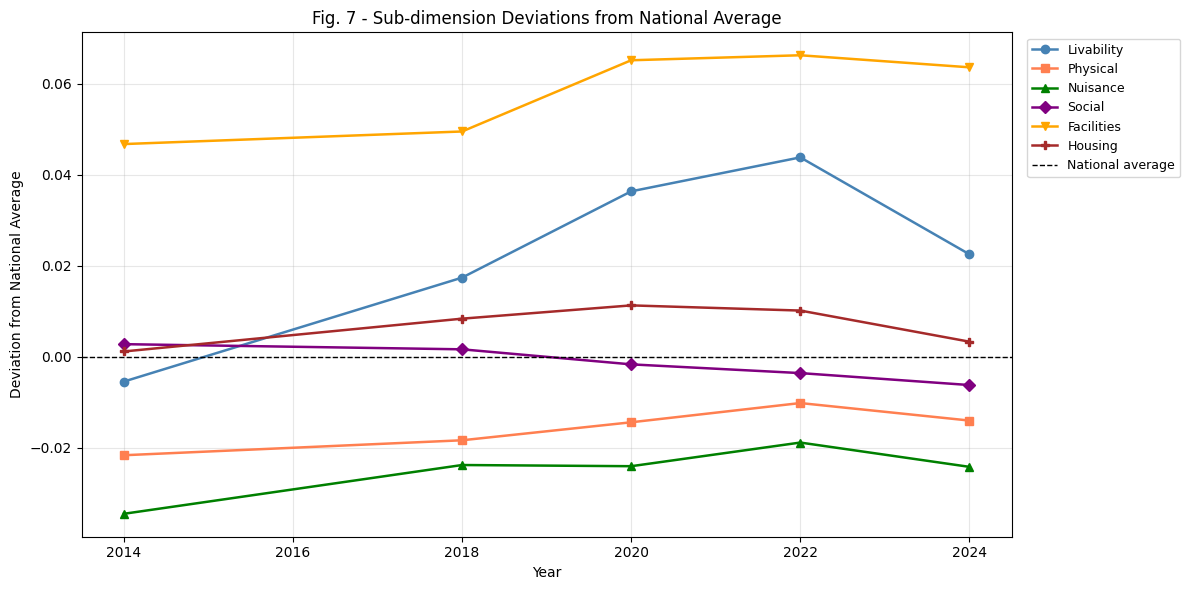

In [76]:
colors = ["steelblue", "coral", "green", "purple", "orange", "brown"]
styles = ["-o", "-s", "-^", "-D", "-v", "-P"]

fig, ax = plt.subplots(figsize=(12, 6))

for i, col in enumerate(dev_cols):
    subset = q4_leef[["year", col]].dropna()
    ax.plot(subset["year"], subset[col],
            styles[i], color=colors[i],
            label=col.replace("avg", "").replace("Deviation", ""),
            linewidth=1.8, markersize=6)

ax.axhline(0, color="black", linewidth=1.0, linestyle="--", label="National average")
ax.set_xlabel("Year")
ax.set_ylabel("Deviation from National Average")
ax.set_title("Fig. 7 - Sub-dimension Deviations from National Average")
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("../output/rq1_q4_subdimension_deviations.png", dpi=150)
plt.show()

## Query 5 - Fastest Improving and Declining Neighborhoods

In [79]:
q5_df = pd.read_csv('../data/processed/rq1-q5-p1.csv')
q5_df.columns = q5_df.columns.str.strip()

for col in ["minScore", "maxScore", "scoreRange", "avgScore"]:
    q5_df[col] = pd.to_numeric(q5_df[col], errors="coerce")

# Loading second query data to ge tthe top 20 neighborhoods later.
q5_scores_df = pd.read_csv('../data/processed/rq1-q5-p2.csv')
q5_scores_df.columns = q5_scores_df.columns.str.strip()
q5_scores_df["year"] = pd.to_numeric(q5_scores_df["year"], errors="coerce").astype(int)
q5_scores_df["livabilityScore"] = pd.to_numeric(
    q5_scores_df["livabilityScore"], errors="coerce"
)

In [80]:
# We determine the direction for top 20 neighborhoods in terms of livability score.
top20 = q5_df["neighborhood"].tolist()
scores_top20 = q5_scores_df[
    q5_scores_df["neighborhood"].isin(top20)
].sort_values(["neighborhood", "year"])

first_scores = scores_top20.groupby("neighborhood")["livabilityScore"].first()
last_scores  = scores_top20.groupby("neighborhood")["livabilityScore"].last()

direction_df = pd.DataFrame({
    "first_score": first_scores,
    "last_score":  last_scores
}).reset_index()

direction_df["direction_delta"] = (
    direction_df["last_score"] - direction_df["first_score"]
)
direction_df["direction"] = direction_df["direction_delta"].apply(
    lambda x: "Improving" if x > 0 else "Declining"
)

q5_df = q5_df.merge(direction_df, on="neighborhood", how="left")

print(f"Improving: {(q5_df['direction'] == 'Improving').sum()}")
print(f"Declining: {(q5_df['direction'] == 'Declining').sum()}")
print(q5_df[["neighborhood", "scoreRange", "direction",
             "direction_delta"]].to_string(index=False))

Improving: 12
Declining: 8
       neighborhood  scoreRange direction  direction_delta
       Castiliëlaan    0.648554 Declining        -0.530982
          Vredeoord    0.521488 Improving         0.105060
            Meerbos    0.308600 Declining        -0.034689
         TU-terrein    0.267279 Improving         0.267279
           Herdgang    0.259588 Declining        -0.188260
               BeA2    0.227985 Improving         0.065469
                Esp    0.185384 Improving         0.056735
       Hondsheuvels    0.179069 Declining        -0.076126
           Urkhoven    0.162820 Improving         0.054798
         Mispelhoef    0.160200 Declining        -0.156216
         Witte Dame    0.155788 Declining        -0.155788
  Eindhoven Airport    0.152164 Declining        -0.036649
       Woensel-West    0.148920 Improving         0.110131
         Fellenoord    0.147021 Improving         0.146776
        Rapelenburg    0.143660 Declining        -0.097732
        Philipsdorp    0.1433

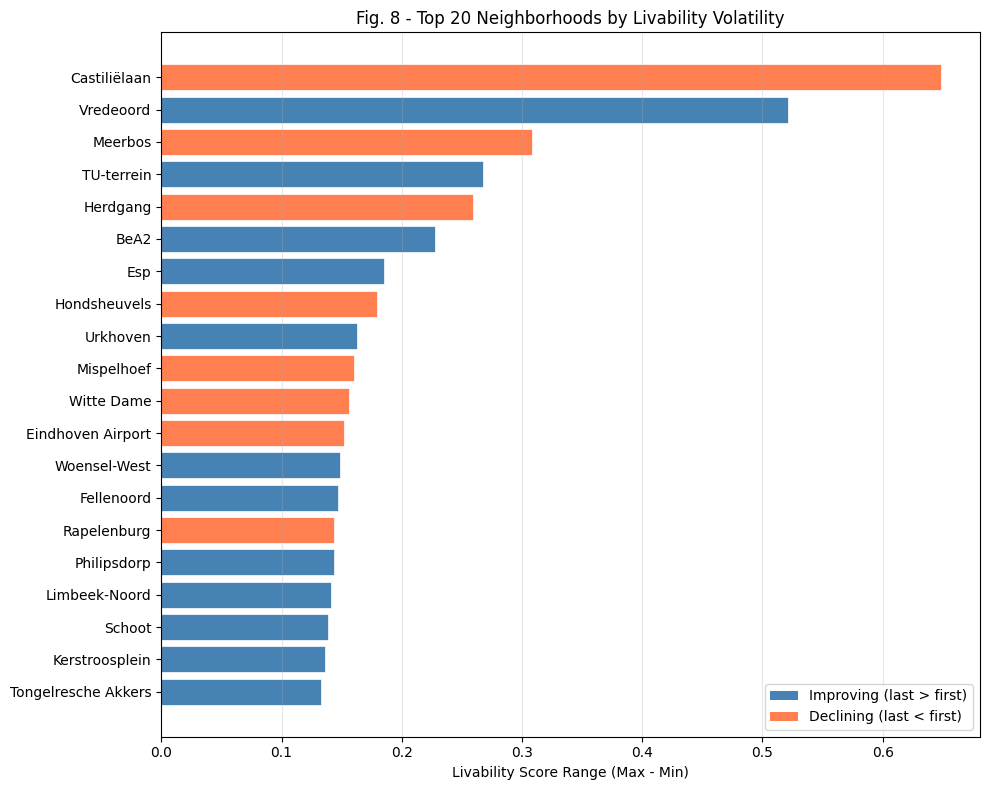

In [81]:
from matplotlib.patches import Patch

q5_sorted = q5_df.sort_values("scoreRange", ascending=True)
colors_bar = ["coral" if d == "Declining" else "steelblue"
              for d in q5_sorted["direction"]]

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(q5_sorted["neighborhood"], q5_sorted["scoreRange"],
        color=colors_bar, edgecolor="white", linewidth=0.5)

legend_elements = [
    Patch(facecolor="steelblue", label="Improving (last > first)"),
    Patch(facecolor="coral",     label="Declining (last < first)")
]
ax.legend(handles=legend_elements, loc="lower right")
ax.set_xlabel("Livability Score Range (Max - Min)")
ax.set_title("Fig. 8 - Top 20 Neighborhoods by Livability Volatility")
ax.grid(True, alpha=0.3, axis="x")
plt.tight_layout()
plt.savefig("../output/rq1_q5_volatility.png", dpi=150)
plt.show()

**Fig. 8** - 
- The top 20 is roughly split with 12 improving and 8 declining.
    - This should ideally be higher if the city is doing well across all neighborhoods, which could suggest a difference in provision of ammenities across neighborhoods.
- Castiliëlaan is a clear outlier with a score range of ~0.65, nearly double the second-highest (Vredeoord at ~0.52), and is declining, suggesting that it should be the focus of intervention.

In [82]:
# We use Query 3 population deltas to include as enrichment to our existing data.
pop_delta_avg = (
    q3_df.groupby("neighborhood")["populationDelta"]
    .mean()
    .reset_index()
    .rename(columns={"populationDelta": "avgPopDelta"})
)

q5_enriched = q5_df.merge(pop_delta_avg, on="neighborhood", how="left")

print("\nTop 20: livability volatility vs avg population delta:")
print(q5_enriched[["neighborhood", "scoreRange", "direction",
                    "direction_delta", "avgPopDelta"]].to_string(index=False))


Top 20: livability volatility vs avg population delta:
       neighborhood  scoreRange direction  direction_delta  avgPopDelta
       Castiliëlaan    0.648554 Declining        -0.530982    95.800000
          Vredeoord    0.521488 Improving         0.105060    -9.400000
            Meerbos    0.308600 Declining        -0.034689     2.600000
         TU-terrein    0.267279 Improving         0.267279   117.000000
           Herdgang    0.259588 Declining        -0.188260    -0.200000
               BeA2    0.227985 Improving         0.065469    -1.400000
                Esp    0.185384 Improving         0.056735     1.400000
       Hondsheuvels    0.179069 Declining        -0.076126    24.600000
           Urkhoven    0.162820 Improving         0.054798     2.200000
         Mispelhoef    0.160200 Declining        -0.156216    -1.800000
         Witte Dame    0.155788 Declining        -0.155788   246.400000
  Eindhoven Airport    0.152164 Declining        -0.036649          NaN
       W

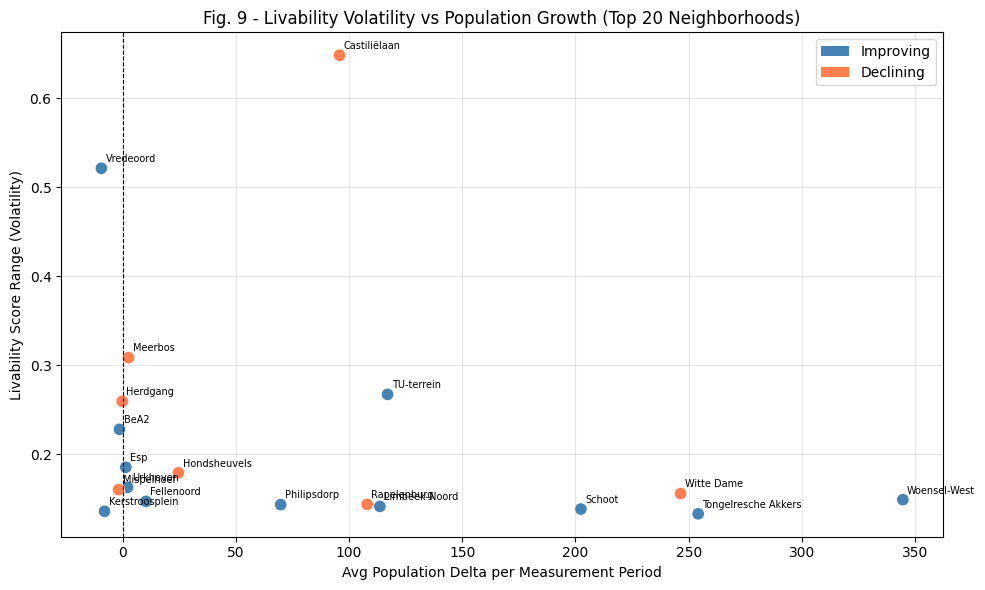

In [83]:
colors_scatter = ["coral" if d == "Declining" else "steelblue"
                  for d in q5_enriched["direction"]]

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(q5_enriched["avgPopDelta"], q5_enriched["scoreRange"],
           color=colors_scatter, s=80, edgecolors="white", linewidth=0.5)

for _, row in q5_enriched.iterrows():
    ax.annotate(row["neighborhood"],
                (row["avgPopDelta"], row["scoreRange"]),
                fontsize=7, ha="left", va="bottom",
                xytext=(3, 3), textcoords="offset points")

ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_xlabel("Avg Population Delta per Measurement Period")
ax.set_ylabel("Livability Score Range (Volatility)")
ax.set_title("Fig. 9 - Livability Volatility vs Population Growth (Top 20 Neighborhoods)")

legend_elements = [
    Patch(facecolor="steelblue", label="Improving"),
    Patch(facecolor="coral",     label="Declining")
]
ax.legend(handles=legend_elements)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("../output/rq1_q5_volatility_vs_population.png", dpi=150)
plt.show()

**Fig. 9** - 
- We plot each of the 20 most volatile neighborhoods by two dimensions simultaneously, their average population growth per period (x-axis) and their livability volatility (y-axis), colored by whether they ultimately improved or declined. 
- We observe no clear pattern between population growth and volatility direction.
- Castiliëlaan stands out as both high-growth and high-volatility declining which is consistent with the stressed neighborhood findings from Query 3.

## Query 6 - Urbanity Class Comparison

In [85]:
q6_df = pd.read_csv('../data/processed/rq1-q6.csv')
q6_df.columns = q6_df.columns.str.strip()
q6_df["year"] = pd.to_numeric(q6_df["year"], errors="coerce").astype(int)
q6_df["avgLivability"] = pd.to_numeric(q6_df["avgLivability"], errors="coerce")
q6_df["avgPopulation"] = pd.to_numeric(q6_df["avgPopulation"], errors="coerce")
q6_df["neighborhoodCount"] = pd.to_numeric(q6_df["neighborhoodCount"], errors="coerce")

measurement_years = [2014, 2016, 2018, 2020, 2022, 2024]
q6_leef = q6_df[
    q6_df["year"].isin(measurement_years) &
    q6_df["avgLivability"].notna()
].copy()

print(q6_leef.to_string(index=False))

      urbanityClass  year  avgLivability  avgPopulation  neighborhoodCount
   Moderately urban  2014       4.170589    1738.750000                 24
   Moderately urban  2016       4.188925    1747.125000                 16
   Moderately urban  2018       4.219298    1800.562500                 16
   Moderately urban  2020       4.219273    1869.812500                 16
   Moderately urban  2022       4.228718    1814.823529                 17
   Moderately urban  2024       4.221277    1597.250000                 16
          Not urban  2014       4.302538      98.333333                  6
          Not urban  2016       4.262689      60.400000                  5
          Not urban  2018       4.266461      57.400000                  5
          Not urban  2020       4.254945      57.200000                  5
          Not urban  2022       4.212576      65.200000                  5
          Not urban  2024       4.249829      60.400000                  5
     Slightly urban  2014

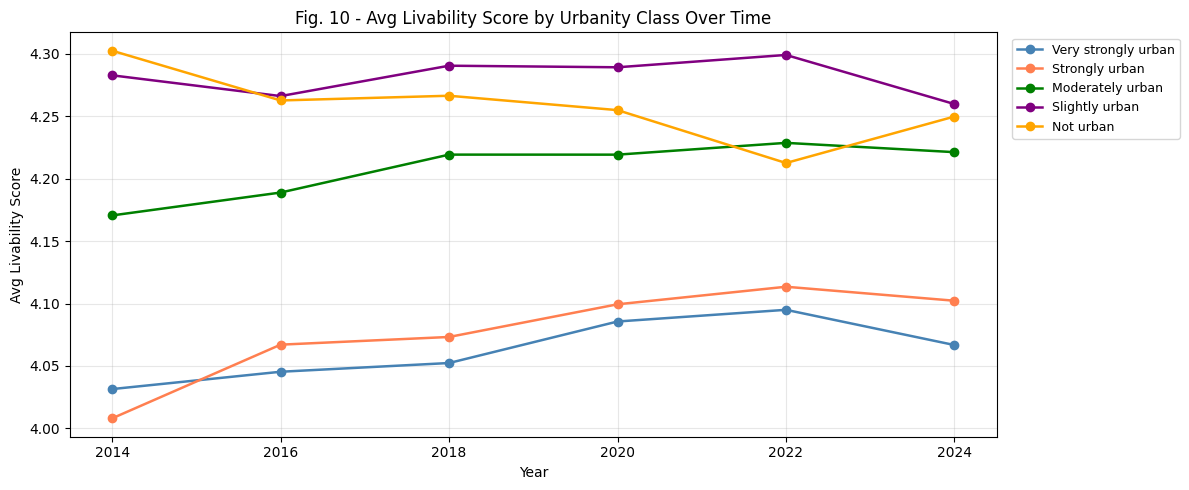

In [86]:
urbanity_order = [
    "Very strongly urban", "Strongly urban", "Moderately urban",
    "Slightly urban", "Not urban"
]
colors = ["steelblue", "coral", "green", "purple", "orange"]

fig, ax = plt.subplots(figsize=(12, 5))

for i, uc in enumerate(urbanity_order):
    subset = q6_leef[q6_leef["urbanityClass"] == uc].sort_values("year")
    if subset.empty:
        continue
    ax.plot(subset["year"], subset["avgLivability"],
            "-o", color=colors[i], linewidth=1.8,
            markersize=6, label=uc)

ax.set_xlabel("Year")
ax.set_ylabel("Avg Livability Score")
ax.set_title("Fig. 10 - Avg Livability Score by Urbanity Class Over Time")
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("../output/rq1_q6_livability_by_urbanity.png", dpi=150,
            bbox_inches="tight")
plt.show()

**Fig. 10** - 
- The key observation from this figure is that the livability is generally lower for more urban areas in comparison to rural areas.

In [88]:
first = q6_leef[q6_leef["year"] == 2014].set_index("urbanityClass")["avgLivability"]
last  = q6_leef[q6_leef["year"] == 2024].set_index("urbanityClass")["avgLivability"]

delta = (last - first).round(4).rename("livabilityDelta")
pop_2024 = q6_leef[q6_leef["year"] == 2024].set_index("urbanityClass")["avgPopulation"]

summary = pd.concat([first, last, delta, pop_2024], axis=1)
summary.columns = ["score_2014", "score_2024", "delta", "avg_pop_2024"]
print("\nLivability change 2014→2024 by urbanity class:")
print(summary.to_string())


Livability change 2014→2024 by urbanity class:
                     score_2014  score_2024   delta  avg_pop_2024
urbanityClass                                                    
Moderately urban       4.170589    4.221277  0.0507   1597.250000
Not urban              4.302538    4.249829 -0.0527     60.400000
Slightly urban         4.282820    4.259797 -0.0230    828.545455
Strongly urban         4.008035    4.102251  0.0942   2928.000000
Very strongly urban    4.031479    4.066751  0.0353   2538.235294


The 2024 livability drop is not concentrated in dense urban neighborhoods, in fact "Very strongly urban" (+0.035) and "Strongly urban" (+0.094) both improved from 2014 to 2024. Instead, "Not urban" (-0.053) and "Slightly urban" (-0.023) have noticeable decreases in livability, which challenges the idea that urban density causes livability decline.